# Task 1:

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, exposure

# Parrot.png is not provided, so use the cameraman image.
img = cv2.imread("cameraman.tif", cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError("Image could not be loaded.")

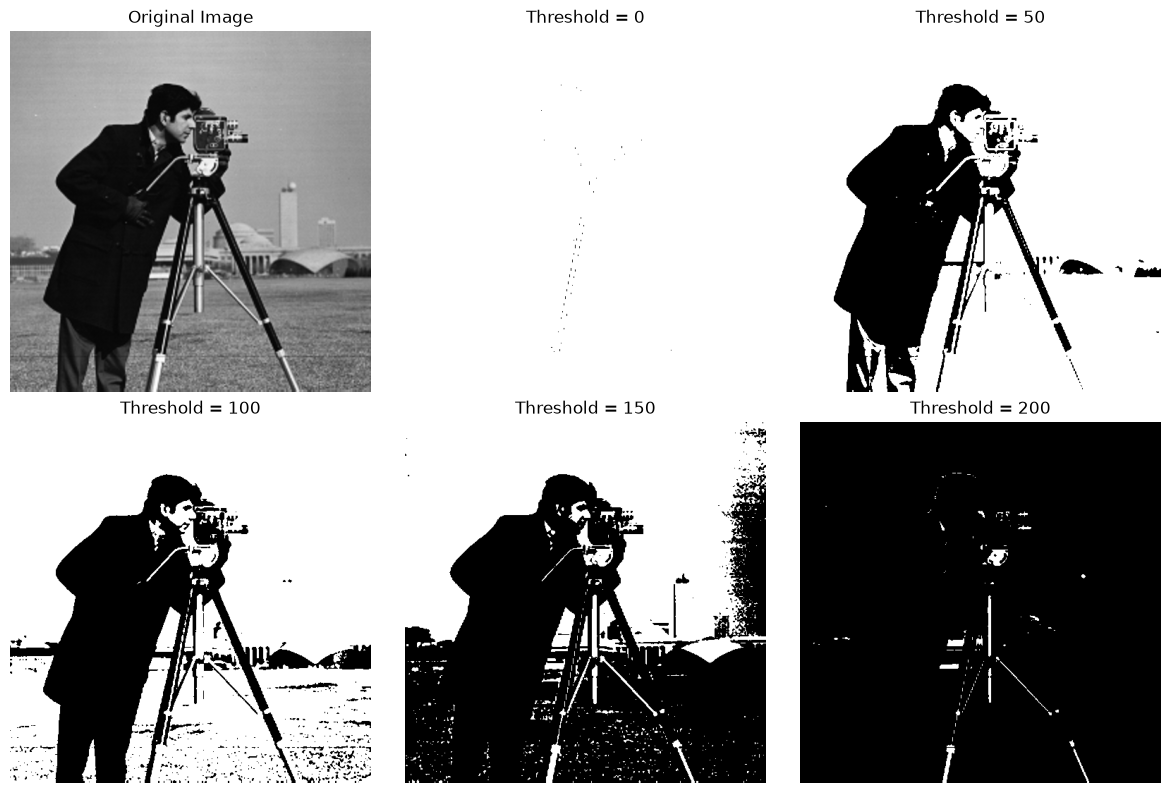

In [2]:
threshold_values = [0, 50, 100, 150, 200]

plt.figure(figsize=(12, 8))
plt.subplot(2, 3, 1)
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.title("Original Image")
plt.axis("off")

for i, threshold_value in enumerate(threshold_values):
    ret, thresh = cv2.threshold(
        img, threshold_value, 255, cv2.THRESH_BINARY
    )

    plt.subplot(2, 3, i + 2)
    plt.imshow(thresh, cmap="gray", vmin=0, vmax=255)
    plt.title(f"Threshold = {threshold_value}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Task 2:

In [3]:
img = data.moon()

# Contrast stretching using the 2nd and 98th percentiles
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

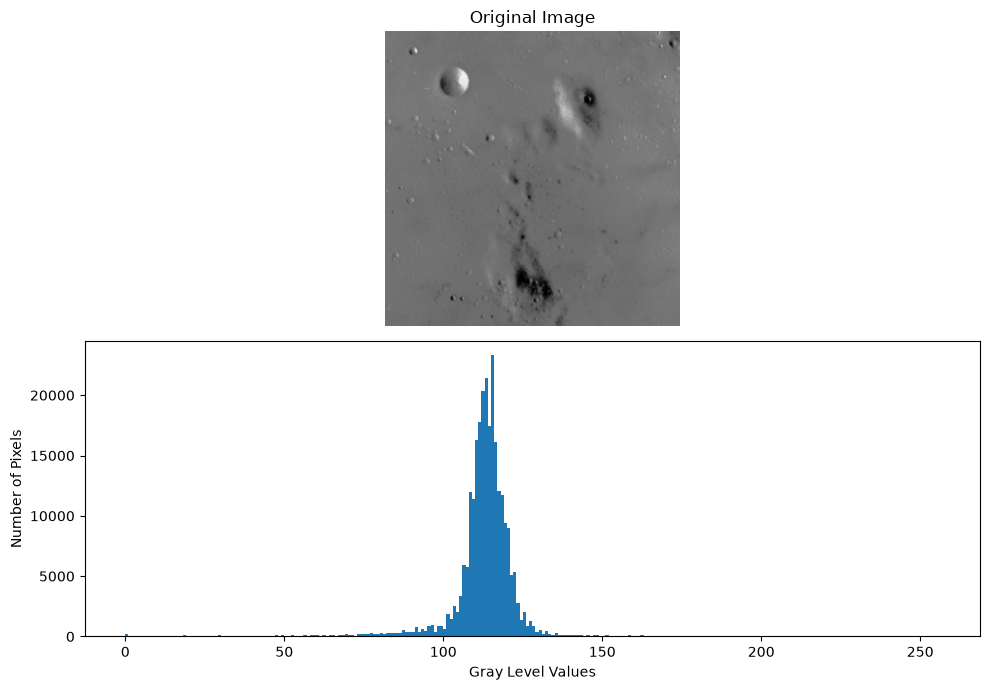

In [4]:
plt.figure(figsize=(10, 7))
plt.subplot(2, 1, 1)
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 1, 2)
plt.hist(img.ravel(), bins=256, range=(0, 256))
plt.xlabel("Gray Level Values")
plt.ylabel("Number of Pixels")

plt.tight_layout()
plt.show()

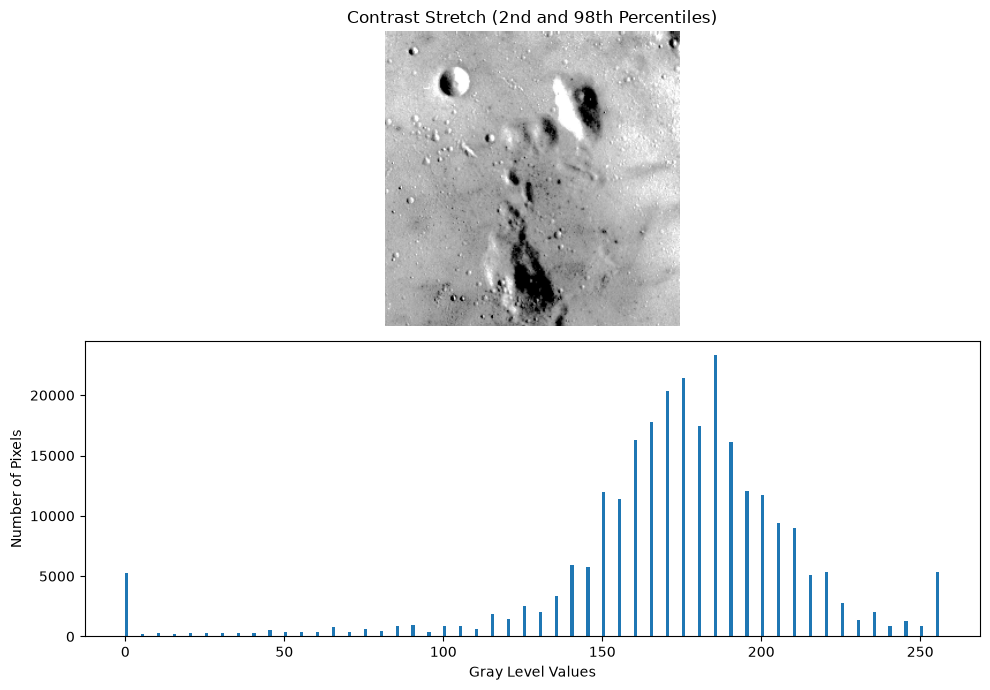

In [5]:
plt.figure(figsize=(10, 7))
plt.subplot(2, 1, 1)
plt.imshow(img_rescale, cmap="gray", vmin=0, vmax=255)
plt.title("Contrast Stretch (2nd and 98th Percentiles)")
plt.axis("off")

plt.subplot(2, 1, 2)
plt.hist(img_rescale.ravel(), bins=256, range=(0, 256))
plt.xlabel("Gray Level Values")
plt.ylabel("Number of Pixels")

plt.tight_layout()
plt.show()

# Assessment Task 1:

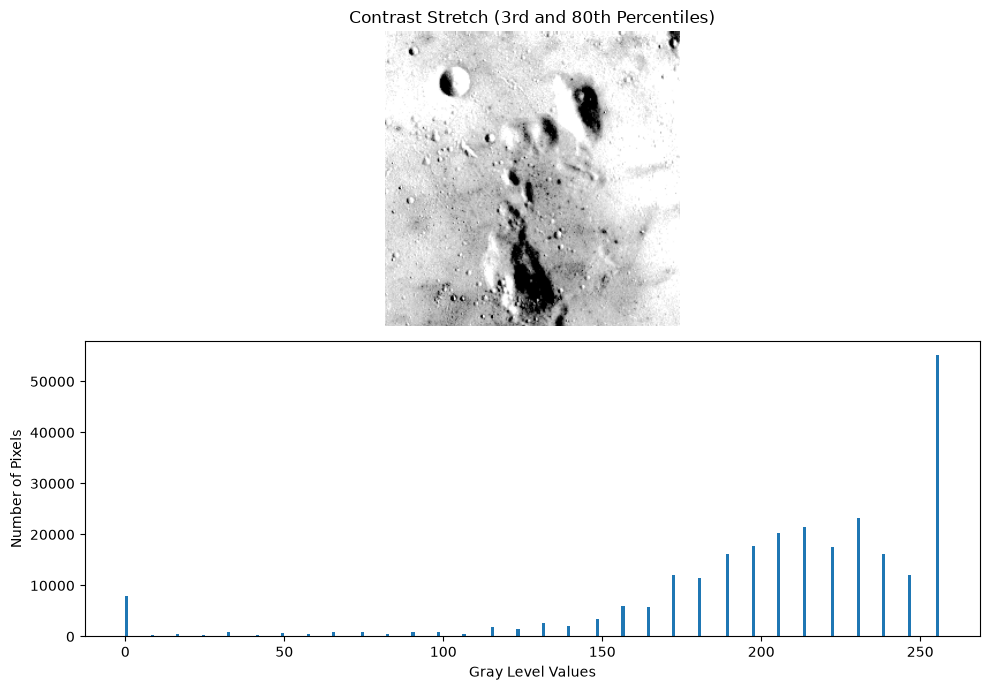

In [6]:
# Contrast stretching using the 3rd and 80th percentiles
p3, p80 = np.percentile(img, (3, 80))
img_rescale_3_80 = exposure.rescale_intensity(img, in_range=(p3, p80))

plt.figure(figsize=(10, 7))
plt.subplot(2, 1, 1)
plt.imshow(img_rescale_3_80, cmap="gray", vmin=0, vmax=255)
plt.title("Contrast Stretch (3rd and 80th Percentiles)")
plt.axis("off")

plt.subplot(2, 1, 2)
plt.hist(img_rescale_3_80.ravel(), bins=256, range=(0, 256))
plt.xlabel("Gray Level Values")
plt.ylabel("Number of Pixels")

plt.tight_layout()
plt.show()

# Assessment Task 2:

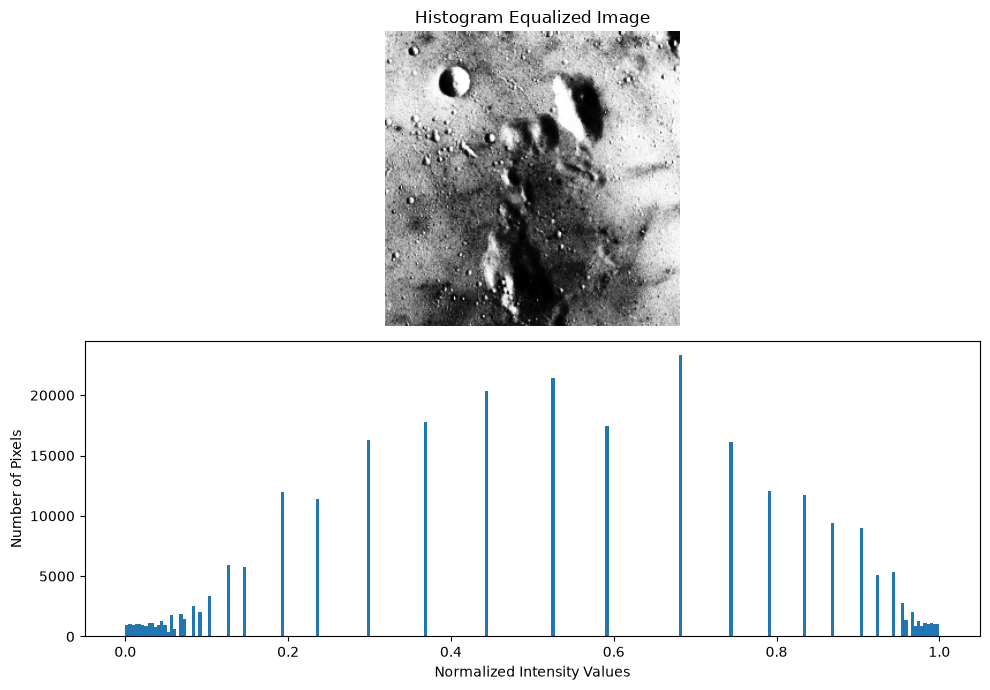

In [7]:
img_equalized = exposure.equalize_hist(img)

plt.figure(figsize=(10, 7))
plt.subplot(2, 1, 1)
plt.imshow(img_equalized, cmap="gray", vmin=0, vmax=1)
plt.title("Histogram Equalized Image")
plt.axis("off")

plt.subplot(2, 1, 2)
plt.hist(img_equalized.ravel(), bins=256, range=(0, 1))
plt.xlabel("Normalized Intensity Values")
plt.ylabel("Number of Pixels")

plt.tight_layout()
plt.show()

# Assessment Task 3:

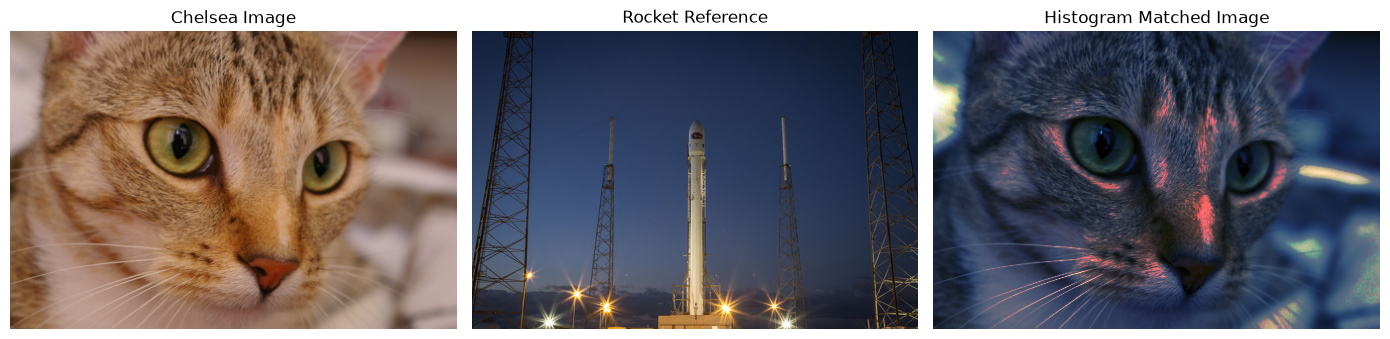

In [8]:
reference = data.rocket()
source = data.chelsea()

# Match Chelsea to the rocket image separately for each RGB channel.
matched = exposure.match_histograms(source, reference, channel_axis=-1)

images = [source, reference, matched]
titles = ["Chelsea Image", "Rocket Reference", "Histogram Matched Image"]

plt.figure(figsize=(14, 5))

for i, (image, title) in enumerate(zip(images, titles)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(image)
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

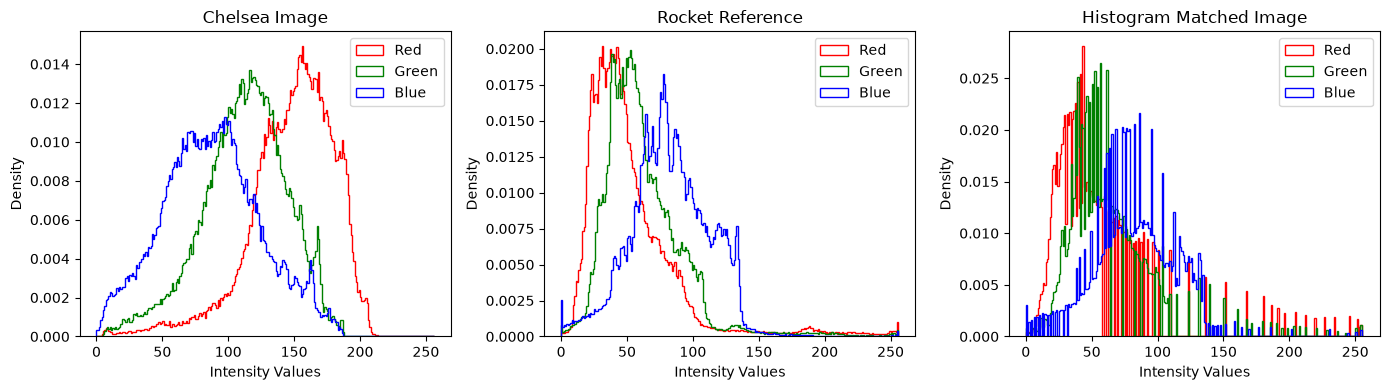

In [9]:
plt.figure(figsize=(14, 4))

for i, (image, title) in enumerate(zip(images, titles)):
    plt.subplot(1, 3, i + 1)

    for channel, color in enumerate(["red", "green", "blue"]):
        plt.hist(
            image[:, :, channel].ravel(),
            bins=256,
            range=(0, 256),
            density=True,
            histtype="step",
            color=color,
            label=color.title()
        )

    plt.title(title)
    plt.xlabel("Intensity Values")
    plt.ylabel("Density")
    plt.legend()

plt.tight_layout()
plt.show()